In [10]:
import numpy as np
import pandas as pd
import xgboost as xgb

In [11]:
# Load the insurance data , should be in the same directory as this script
insurance_data = pd.read_csv('data/insurance_data_raw.csv')

insurance_data = insurance_data.sample(frac=1).reset_index(drop=True)
# Separate features and target variable
target = insurance_data["claim"].values


insurance_data.head(n=9)


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,41.0,female,85,28.1,NoDisease,1,0,Baltimore,0,1,0,ITProfessional,6770.2
1,19.0,male,48,25.1,Arthritis,0,0,Florence,72,0,1,Accountant,14219.2
2,26.0,female,45,29.9,NoDisease,2,0,SanLuis,68,0,1,Blogger,3982.0
3,63.0,male,83,35.1,NoDisease,0,1,Reno,85,1,0,FashionDesigner,47055.5
4,24.0,male,65,40.2,NoDisease,0,1,Charleston,60,1,0,Clerks,38126.3
5,NaN,male,68,27.9,NoDisease,0,0,Atlanta,58,0,0,Architect,2867.1
6,47.0,female,60,29.5,NoDisease,1,0,Atlanta,76,1,0,Chef,8930.9
7,24.0,female,44,25.3,NoDisease,0,0,Phildelphia,50,1,0,Actor,3044.2
8,38.0,female,90,46.0,NoDisease,2,0,Oklahoma,0,1,0,Clerks,7133.9


In [4]:
from sklearn.preprocessing import LabelEncoder

# Remove 'claim' column
insurance_data_no_claim = insurance_data.drop(columns=['claim'])
# Encode string columns to integer
string_columns = insurance_data_no_claim.select_dtypes(include='object').columns
label_encoders = {}

for col in string_columns:
    le = LabelEncoder()
    insurance_data_no_claim[col] = le.fit_transform(insurance_data_no_claim[col])
    label_encoders[col] = le

insurance_data_no_claim.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title
0,52.0,0,50,NaN,8,0,0,54,72,0,0,30
1,51.0,0,74,39.5,8,1,0,41,82,1,0,6
2,46.0,0,70,28.1,8,1,0,75,80,1,0,21
3,52.0,1,91,33.3,8,0,0,50,68,1,0,9
4,58.0,1,81,37.0,9,2,1,13,50,1,0,32


In [5]:
# How to handle missing values ####
insurance_data_no_claim.isna().sum() 
#get the number of missing values in each column
#insurance_data_no_claim = insurance_data_no_claim.dropna()  # Drop rows with missing values
insurance_data_no_claim = insurance_data_no_claim.fillna(insurance_data_no_claim.mean())  # Fill missing values with column mean



# Receive a summary of the dataframe ####
# insurance_data_no_claim.info() get a summary of the dataframe
# insurance_data_no_claim.describe() get a statistical summary of the dataframe

print(insurance_data_no_claim.isna().sum())


age                    0
sex                    0
weight                 0
bmi                    0
hereditary_diseases    0
no_of_dependents       0
smoker                 0
city                   0
bloodpressure          0
diabetes               0
regular_ex             0
job_title              0
dtype: int64


In [6]:
# Discard not significant features

#if "index" in insurance_data_no_claim.columns or "PatientID" in insurance_data_no_claim.columns:
features = insurance_data_no_claim  #.drop(columns=['index', 'PatientID'])


# Standardize numerical features
features["age"] = (features["age"] - features["age"].mean()) / features["age"].std()
features["bloodpressure"] = (features["bloodpressure"] - features["bloodpressure"].mean()) / features["bloodpressure"].std()
features["bmi"] = (features["bmi"] - features["bmi"].mean()) / features["bmi"].std()


# Normalize to [0,1]
max_target = target.max()

target = target / max_target    
target_ind = target.copy()


# Split the dataset into training, validation, and test sets ####
from sklearn.model_selection import train_test_split

# Split the data into train, validation, and test sets (e.g., 60% train, 20% val, 20% test)

# First split into train and temp (train: 60%, temp: 40%)
X_temp, X_test, y_temp, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

print("Train set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

Train set size: (9000, 12)
Validation set size: (3000, 12)
Test set size: (3000, 12)


In [19]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr
import numpy as np

model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
pearsonr_coeff, _ = pearsonr(y_test, y_pred)
spearmanr_coeff, _ = spearmanr(y_test, y_pred)


print(f'Spearman r: {spearmanr_coeff:.3f}')
print(f'Pearson r: {pearsonr_coeff:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

Spearman r: 0.978
Pearson r: 0.979
RMSE: 0.038
R²: 0.959


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.5, 0.8, 1.0],
    'colsample_bytree': [0.5 ,0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)
print("Best parameters:", grid_search.predict(X_test))

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 9, 'subsample': 1.0}
Best cross-validation score: 0.9695194144577771


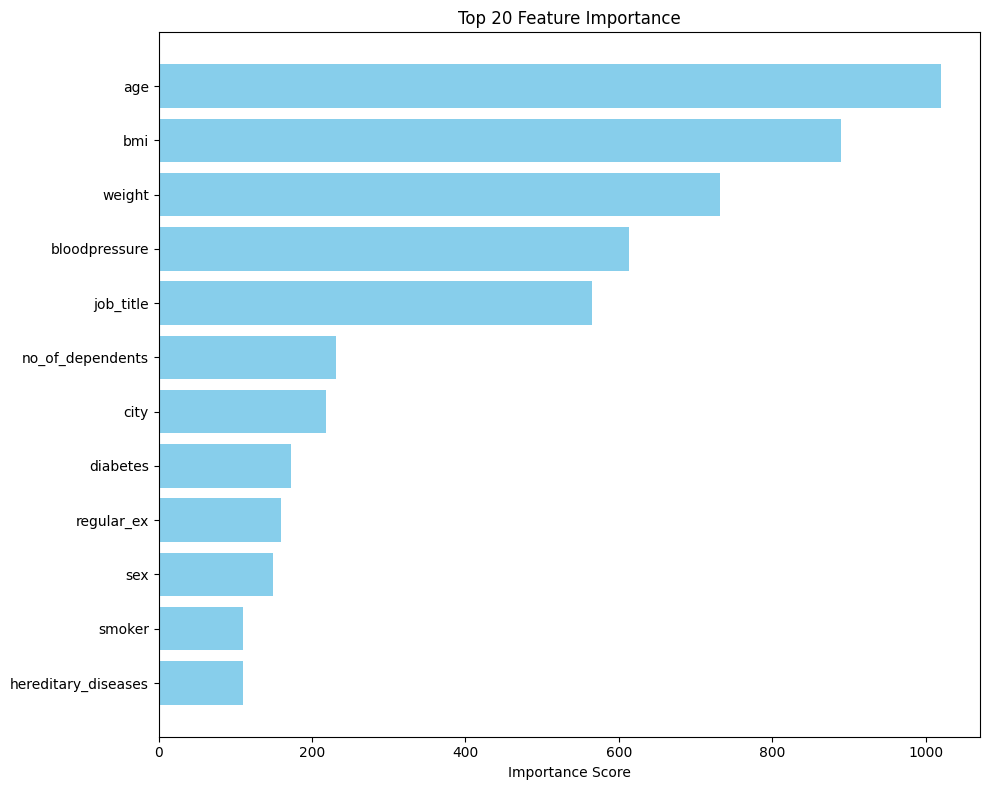

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

importance = model.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()